# FAIDR — interactive notebook

This notebook runs the **FAIDR** pipeline to predict which intrinsically disordered regions (IDRs) belong to a cellular compartment or functional category.

Publication: https://doi.org/10.7554/eLife.60220

**What you get at the end:**
- A cross-validation ROC plot (model quality)
- Summary metrics → `FAIDR_output/<category>/run_summary.tsv`
- Per-IDR predictions → `FAIDR_output/<category>/idr_predictions.tsv`
- A Venn diagram: annotated positives vs. consistently predicted positives

> **Runtime:** with default settings (100 repetitions) expect **tens of minutes**. Two progress bars show the current stage.

## Environment & packages

Open this notebook from the project folder (`FAIDR_pretty`). You need **Python** (in a virtual environment) and **R** (installed on your computer).

### 1. Python — create a virtual environment (one-time, in Terminal)

Create a virtual environment:

```bash
cd FAIDR_pretty
python3 -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate
pip install -r requirements.txt
python -m ipykernel install --user --name=faidr --display-name "FAIDR (.venv)"
```

Then in Jupyter / Cursor / VS Code select the kernel **FAIDR (.venv)**.

**Python version:** use **3.10, 3.11, or 3.12** (recommended for `rpy2`).

### 2. R — install on your machine (one-time)

| OS | Typical install |
|----|-----------------|
| macOS | `brew install r` |
| Linux | `sudo apt install r-base` or use your cluster module |
| Windows | installer from https://cran.r-project.org |

R packages **`glmnet`** and **`pROC`** — install once in the **R packages (run once)** cell below, then use **Imports for analysis** each session.

## R packages (run once)

Installs `glmnet` and `pROC` into your **system R library** if missing. Run **once per machine** (or after a fresh R install).

In [2]:
import rpy2.robjects as ro

cran = "https://cloud.r-project.org"
for pkg in ("glmnet", "pROC"):
    ro.r(
        f'if (!requireNamespace("{pkg}", quietly=TRUE)) '
        f'install.packages("{pkg}", repos="{cran}")'
    )
print("Done — glmnet and pROC are installed (or were already present).")

## Imports for analysis

Run at the start of each session. Python libraries + `run_faidr_cv` (the script loads R packages via `importr` — no `library()` needed here).

In [ ]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

from iva_FAIDR_cv_notebook import run_faidr_cv

## Step 1 — Set parameters

Defaults below match the standard example (nucleolus, evolutionary features).

You can change:
- `target_file` — any annotation `.tsv` with columns `idr_name` and a 0/1 label
- `feature_type` — `"evolutionary"` (HUMAN_ES.txt) or `"signature"` (FS_…txt)
- `specificity` — threshold used to pick the classification cutoff (default 0.99)
- `n_reps` — number of repetitions (default 100; use a smaller value for a quick test)

**Input files** (included in this repo by default):

*Feature matrices* — set `feature_type` to choose one:
- `HUMAN_ES.txt` — evolutionary features (default)
- `FS_UP000005640_9606_SPOTD_MIN_30AA.txt` — signature features

*Annotation file* (example):
- `HIGH_AUC_PPV_FILTERED_FUNCTIONS/GO0005730_nucleolus.tsv` — nucleolus labels (0/1)

In [5]:
# target_file = "HIGH_AUC_PPV_FILTERED_FUNCTIONS/GO0005730_nucleolus.tsv"
# target_file = "HIGH_AUC_PPV_FILTERED_FUNCTIONS/nucleolus_MLO.tsv"
target_file = "HIGH_AUC_PPV_FILTERED_FUNCTIONS/EWS_enrich_EF.tsv"
feature_type = "evolutionary"   # "evolutionary" | "signature"
features_path = None            # or an explicit path to a features file
specificity = 0.99
n_reps = 10

consistency_cutoff = 0.5        # for the Venn diagram below

## Step 2 — Run FAIDR

Click **Run** on the cell below and wait until both progress bars finish.

| Progress bar | What it does |
|---|---|
| **Step 1/2 — Cross-validation (ROC / AUC)** | Repeated cross-validation to estimate how well the model generalizes |
| **Step 2/2 — Final training (IDR predictions)** | Repeated training on all data to produce per-IDR probabilities and consistency scores |

**Will ROC curves appear?** Yes. After Step 1 finishes, a ROC plot is drawn automatically in the notebook (one faint curve per repetition, mean AUC in the title). You do not need a separate plotting step.

Step 1/2 — Cross-validation (ROC / AUC):   0%|          | 0/10 [00:00<?, ?run/s]

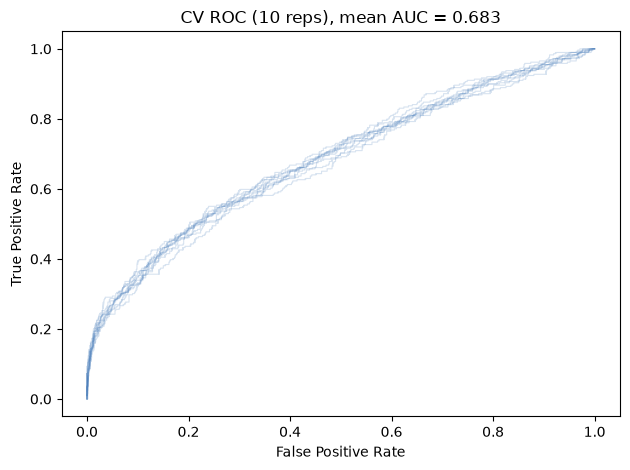

Step 2/2 — Final training (IDR predictions):   0%|          | 0/10 [00:00<?, ?run/s]

In [ ]:
result = run_faidr_cv(
    target_file=target_file,
    feature_type=feature_type,
    features_path=features_path,
    specificity=specificity,
    n_reps=n_reps,
    show_progress=True,
)

print("Done. Output folder:", result["out_dir"])

## Step 3 — Summary metrics

One-row table with overall run statistics. Key columns:

- **IDR_AUC_CV** — mean cross-validation AUC at IDR level (higher is better)
- **Prot_AUC_CV** — mean AUC at protein level
- **thresh** — average probability cutoff chosen from the ROC curve
- **N_annotated_IDRs** — how many IDRs were labeled positive in your annotation file

In [7]:
summary = result["classi_info"].T
summary.columns = ["value"]
summary.index.name = "metric"
display(summary)

print("\nSaved to:", result["out_dir"] / "run_summary.tsv")

,value
metric,
category,EWS_enrich_EF
thresh,0.575304
above_thresh_in_annotated,55.0
above_thresh_not_in_annotated,276.1
IDR_AUC_CV,0.682824
Prot_AUC_CV,0.817374
N_annotated_IDRs,289.0



Saved to: FAIDR_output/EWS_enrich_EF/run_summary.tsv


## Step 4 — Per-IDR predictions (preview)

Each row is one IDR. Important columns:

- **mean_probability** — average predicted probability across all repetitions
- **consistency_fraction** — fraction of repetitions where the IDR was called positive (above the learned threshold); ranges from 0 to 1

In [8]:
predictions = result["idr_results"]
display(predictions.head(10))
print(f"\nTotal IDRs: {len(predictions):,}")
print("Saved to:", result["out_dir"] / "idr_predictions.tsv")

,uniprot_accession,idr_name,mean_probability,consistency_fraction
0,Q5VUJ6,Q5VUJ6_IDR_1_54,0.279381,0.0
1,Q8TD19,Q8TD19_IDR_825_961,0.166037,0.0
2,Q9H425,Q9H425_IDR_129_306,0.109424,0.0
3,Q8NBI5,Q8NBI5_IDR_214_268,0.150388,0.0
4,P36941,P36941_IDR_369_411,0.178322,0.0
5,P82912,P82912_IDR_37_70,0.143139,0.0
6,Q96BY7,Q96BY7_IDR_238_276,0.139979,0.0
7,Q9H5H4,Q9H5H4_IDR_1_262,0.249922,0.0
8,Q6PGQ7,Q6PGQ7_IDR_1_103,0.158010,0.0
9,Q9NP74,Q9NP74_IDR_246_406,0.172883,0.0



Total IDRs: 19,032
Saved to: FAIDR_output/EWS_enrich_EF/idr_predictions.tsv


## Step 5 — Venn diagram: annotation vs. consistent FAIDR predictions

We compare two sets of IDRs:

1. **Annotated positives** — IDRs labeled `1` in your annotation file (known positives for this category)
2. **Consistently predicted positives** — IDRs with `consistency_fraction ≥ 0.5` (called positive in at least half of the training repetitions)

The **overlap** shows IDRs that were both annotated and reliably recovered by FAIDR.
IDRs only on the left were annotated but not consistently predicted; only on the right were consistently predicted but not in the original annotation.

Category: enrich
Consistency cutoff: 0.5
Annotated positives:              289
Consistently predicted positives: 317
Overlap:                          58
Only annotated:                   231
Only predicted:                   259


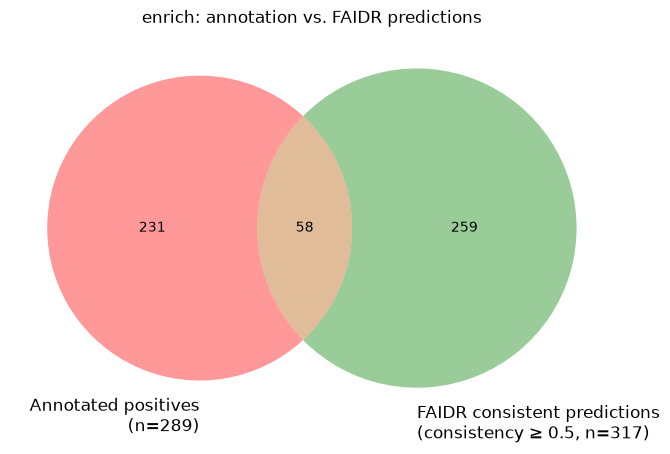

In [9]:
annotation = pd.read_csv(target_file, sep="\t")
label_col = annotation.columns[1]
category_label = label_col

annotated_positive = set(annotation.loc[annotation[label_col] == 1, "idr_name"])
consistent_predicted = set(
    predictions.loc[predictions["consistency_fraction"] >= consistency_cutoff, "idr_name"]
)

overlap = annotated_positive & consistent_predicted
only_annotated = annotated_positive - consistent_predicted
only_predicted = consistent_predicted - annotated_positive

print(f"Category: {category_label}")
print(f"Consistency cutoff: {consistency_cutoff}")
print(f"Annotated positives:              {len(annotated_positive):,}")
print(f"Consistently predicted positives: {len(consistent_predicted):,}")
print(f"Overlap:                          {len(overlap):,}")
print(f"Only annotated:                   {len(only_annotated):,}")
print(f"Only predicted:                   {len(only_predicted):,}")

fig, ax = plt.subplots(figsize=(7, 6))
venn2(
    subsets=(len(only_annotated), len(only_predicted), len(overlap)),
    set_labels=(
        f"Annotated positives\n(n={len(annotated_positive):,})",
        f"FAIDR consistent predictions\n(consistency ≥ {consistency_cutoff}, n={len(consistent_predicted):,})",
    ),
    ax=ax,
)
ax.set_title(f"{category_label}: annotation vs. FAIDR predictions")
plt.tight_layout()
plt.show()